In [ ]:
# ---------------------- 1. MOUNT DRIVE ----------------------
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# ---------------------- 2. INSTALL PACKAGE ------------------
!pip install ultralytics --upgrade
!pip install matplotlib seaborn scikit-learn pandas

from ultralytics import YOLO
import os, glob, shutil
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image
import numpy as np
import pandas as pd
import torch

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 49.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# ---------------------- 3. CONFIG ---------------------------
DATA_ROOT   = "/content/drive/MyDrive/Dataset Fix Bounding Box"
DATA_YAML   = "/content/drive/MyDrive/Dataset Fix Bounding Box/data.yaml"
MODEL_SAVE  = "/content/drive/MyDrive/yolo_v9_best224_sd121.pt"

IMG_SIZE = 224
BATCH    = 32
EPOCHS   = 100

device = 0 if torch.cuda.is_available() else "cpu"
print("📌 Device:", device)

# ---------------------- 4. TRAINING -------------------------
print("\n🚀 Start training YOLOv9 ...\n")

model = YOLO("yolov9s.pt")

results = model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=device,
    patience=15,
    amp=True,
    workers=8,

    hsv_h=0.02,
    hsv_s=0.2,
    hsv_v=0.2,

    degrees=15.0,
    scale=0.2,
    translate=0.0,
    shear=0.0,

    fliplr=0.5,
    flipud=0.0,
    mosaic=0.0,
    mixup=0.0,
)

print("\n>>> Training selesai! Cek folder runs/detect/train/weights\n")

# ---------------------- 5. SAVE MODEL TERBAIK ---------------
best_model_path = "runs/detect/train/weights/best.pt"
if os.path.exists(best_model_path):
    shutil.copy(best_model_path, MODEL_SAVE)
    print(f"🔥 Model terbaik disimpan ke: {MODEL_SAVE}")
else:
    print("❗Best model tidak ditemukan!")

📌 Device: 0

🚀 Start training YOLOv9 ...

Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Dataset Fix Bounding Box/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.2, hsv_v=0.2, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9s.pt, momentum=0.937, mosaic=0.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, op


📊 Evaluation (VAL Dataset):
Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
YOLOv9s summary (fused): 197 layers, 7,169,797 parameters, 0 gradients, 26.7 GFLOPs
val: Fast image access ✅ (ping: 6.2±13.1 ms, read: 32.8±53.0 MB/s, size: 217.5 KB)
val: Scanning /content/drive/MyDrive/Dataset Fix Bounding Box/validasi/labels.cache... 140 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 140/140 184.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 3.8it/s 2.4s
                   all        140        154      0.862       0.84       0.87      0.732
              Apicalis         20         21      0.865          1       0.94      0.857
              Binghami         20         22      0.864      0.773      0.824      0.749
                 Biroi         20         20      0.862      0.937      0.928      0.846
                 Itama         20         28      0.988     

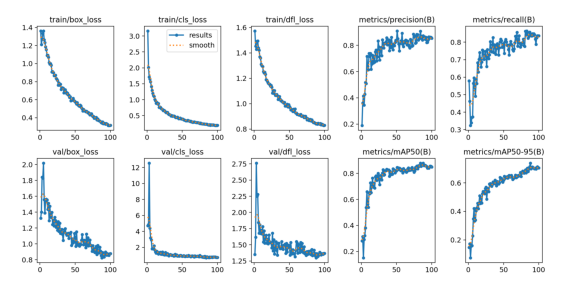

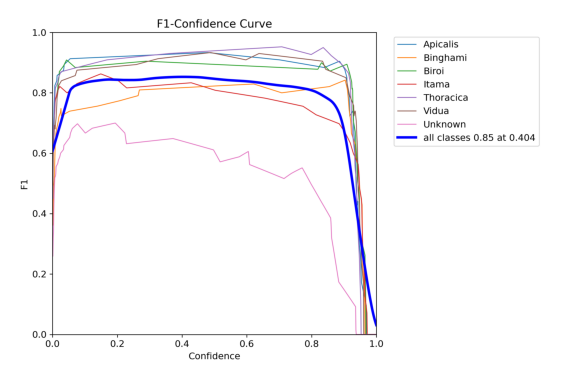

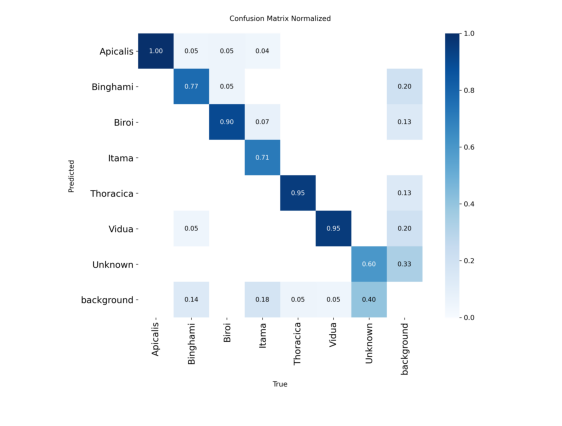

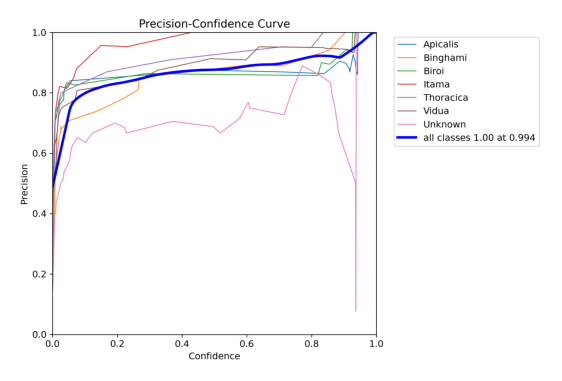

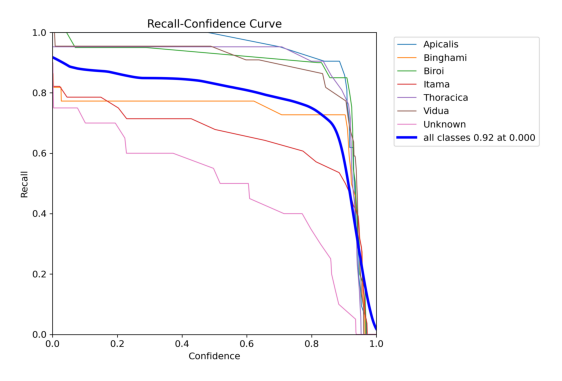

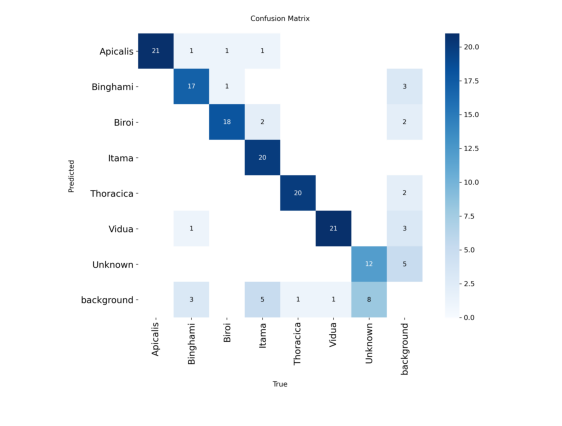

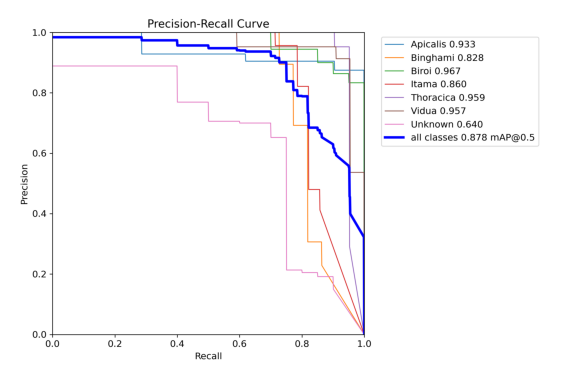


📌 Generate Confusion Matrix (berdasarkan label .txt):


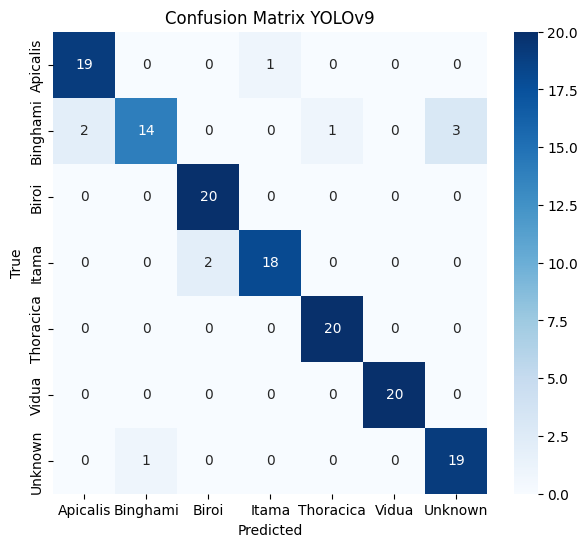


📄 Classification Report:
              precision    recall  f1-score   support

    Apicalis       0.90      0.95      0.93        20
    Binghami       0.93      0.70      0.80        20
       Biroi       0.91      1.00      0.95        20
       Itama       0.95      0.90      0.92        20
   Thoracica       0.95      1.00      0.98        20
       Vidua       1.00      1.00      1.00        20
     Unknown       0.86      0.95      0.90        20

    accuracy                           0.93       140
   macro avg       0.93      0.93      0.93       140
weighted avg       0.93      0.93      0.93       140


🧪 Contoh prediksi otomatis disimpan ke /runs/detect/predict/
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Apicalis', 1: 'Binghami', 2: 'Biroi', 3: 'Itama', 4: 'Thoracica', 5: 'Vidua', 6: 'Unknown'}
 obb: None
 orig_img: array([[[ 23,  21,  13],
         [ 23,  21,  13],
         [ 25,  23,  15],
         ...,
         [149, 168, 175],
         [150, 169, 176],
         [151, 170, 177]],
 
        [[ 23,  21,  13],
         [ 24,  22,  14],
         [ 25,  23,  15],
         ...,
         [151, 170, 177],
         [151, 170, 177],
         [152, 171, 178]],
 
        [[ 23,  21,  13],
         [ 24,  22,  14],
         [ 24,  22,  14],
         ...,
         [153, 172, 179],
         [153, 172, 179],
         [154, 173, 180]],
 
        ...,
 
        [[173, 160, 138],
         [174, 161, 139],
         [177, 164, 142],
         ...,
         [128, 120, 103],
         [126, 118, 101],
         [126, 118, 101]],
 
        [[173, 160, 138],
 

In [ ]:
# ---------------------- 6. EVALUATION AKHIR -----------------
print("\n📊 Evaluation (VAL Dataset):")
eval_metrics = model.val(data=DATA_YAML)
print(eval_metrics)

print("\n🔍 Testing (TEST Dataset):")
test_results = model.val(data=DATA_YAML, split="test")
print(test_results)

# ---------------------- 7. PRINT METRIC DETAIL --------------
# Gunakan mp dan mr, bukan precision/recall
print("\n📌 Performance Metrics:")
print(f"mAP50-95 : {eval_metrics.box.map:.4f}")
print(f"mAP50    : {eval_metrics.box.map50:.4f}")
print(f"mAP75    : {eval_metrics.box.map75:.4f}")
print(f"Precision (mean) : {eval_metrics.box.mp:.4f}")
print(f"Recall (mean)    : {eval_metrics.box.mr:.4f}")

# ---------------------- 8. VISUALISASI LEARNING CURVE -------
print("\n📈 Training Curve & Metrics:")
for img_path in glob.glob("runs/detect/train/*.png"):
    img = Image.open(img_path)
    plt.figure(figsize=(7,7))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

# ---------------------- 9. CONFUSION MATRIX -----------------
print("\n📌 Generate Confusion Matrix (berdasarkan label .txt):")

true_labels, pred_labels = [], []
test_images = glob.glob(f"{DATA_ROOT}/uji/images/*.*")  # pastikan 'test' sesuai data.yaml

for img_path in test_images:
    label_file = img_path.replace("images", "labels").rsplit(".",1)[0] + ".txt"

    # ambil true label dari file annotation
    if os.path.exists(label_file):
        with open(label_file) as f:
            first_label = f.readline().split()[0]  # ambil class pertama
            true_label = model.names[int(first_label)]
    else:
        true_label = "Unknown"

    # prediksi
    result = model.predict(img_path, conf=0.25, verbose=False)
    if len(result[0].boxes) > 0:
        pred_class = model.names[int(result[0].boxes.cls[0])]
    else:
        pred_class = "Unknown"

    true_labels.append(true_label)
    pred_labels.append(pred_class)

# Semua label dari model.names
labels = list(model.names.values())
cm = confusion_matrix(true_labels, pred_labels, labels=labels)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix YOLOv9")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()

print("\n📄 Classification Report:")
print(classification_report(true_labels, pred_labels, labels=labels))

# ---------------------- 10. SAMPLE PREDICTION ----------------
print("\n🧪 Contoh prediksi otomatis disimpan ke /runs/detect/predict/")
sample_folder = f"{DATA_ROOT}/uji/images"
model.predict(source=sample_folder, save=True, conf=0.30)